# Previsão de Churn de Clientes

**Enunciado**: Uma rede de supermercados percebe queda no número de clientes ativos. Você recebeu um dataset histórico de transações e precisa: extrair e preparar os dados via SQL, analisar o comportamento de compra, identificar clientes em risco de abandono e comunicar esses resultados de forma clara para o time de negócio.

Fluxo completo: **SQL (DuckDB) → EDA → Modelo de Classificação → Exportação para Power BI**.

Cada decisão (data de referência, tratamento de dados, definição de churn, escolha de modelo, threshold e
métricas) está comentada ao longo do notebook.

## 0. Configuração do ambiente

In [33]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, RocCurveDisplay, precision_score, recall_score,
                             f1_score, brier_score_loss, precision_recall_curve)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RANDOM_STATE = 42
CSV_PATH = "base_teste_tecnico.csv"
print("Ambiente pronto. DuckDB", duckdb.__version__)

Ambiente pronto. DuckDB 1.5.4


## 1. Carga e diagnóstico de qualidade dos dados (SQL)

O dataset tem imperfeições propositais (negativos, outliers, assimetria). Foi realizado um diagnostico via SQL antes de
qualquer cálculo, para decidir o tratamento de forma documentada.

In [ ]:
import pandas as pd

arquivo_csv = "base_teste_tecnico.csv"
pd.read_csv(arquivo_csv)
arquivo_csv[df


con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE TABLE vendas AS
SELECT
    strptime(CAST(ano_mes_dia AS VARCHAR), '%Y%m%d')::DATE AS data,
    CAST(loja AS VARCHAR) AS loja,
    id_venda,
    id_cliente,
    faturamento
FROM read_csv_auto('{CSV_PATH}')
""")
con.execute(f"""
CREATE OR REPLACE TABLE vendas AS
SELECT
    faturamento\(COUNT(faturamento)) AS ticket_medio
WHERE 
      
FROM read_csv_auto('{CSV_PATH}')
""")
con.execute("""
SELECT
    COUNT(*) AS linhas, COUNT(DISTINCT id_cliente) AS clientes,
    COUNT(DISTINCT id_venda) AS vendas_unicas, COUNT(DISTINCT loja) AS lojas,
    MIN(data) AS primeira_data, MAX(data) AS ultima_data,
    SUM(CASE WHEN faturamento = 0 THEN 1 ELSE 0 END) AS qt_zerados,
    SUM(CASE WHEN faturamento < 0 THEN 1 ELSE 0 END) AS qt_negativos,
    SUM(CASE WHEN faturamento IS NULL THEN 1 ELSE 0 END) AS qt_nulos,
    ROUND(MIN(faturamento),2) AS fat_min, ROUND(MAX(faturamento),2) AS fat_max,
    ROUND(MEDIAN(faturamento),2) AS fat_mediana, ROUND(AVG(faturamento),2) AS fat_media
FROM vendas
""").df().T

<>:26: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:26: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
C:\Users\Jooj\AppData\Local\Temp\ipykernel_22604\873157185.py:26: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  COUNT(*) AS linhas, COUNT(DISTINCT id_cliente) AS clientes,


ParserException: Parser Error: syntax error at or near "\"

LINE 4:     faturamento\(COUNT(faturamento)) AS ticket_medio
                       ^

**Leitura do diagnóstico**
- 309.178 transações, 11.684 clientes, 2 lojas, período 2025-01-02 a 2026-05-31 (~17 meses).
- `id_venda` único (sem duplicatas), sem nulos nas chaves.
- Sem faturamento zerado, mas 286 valores negativos (mín. -1.151) → devoluções/estornos.
- Média (78,3) >> mediana (48,9), máximo 7.000 → distribuição assimétrica à direita com outliers de alto valor.

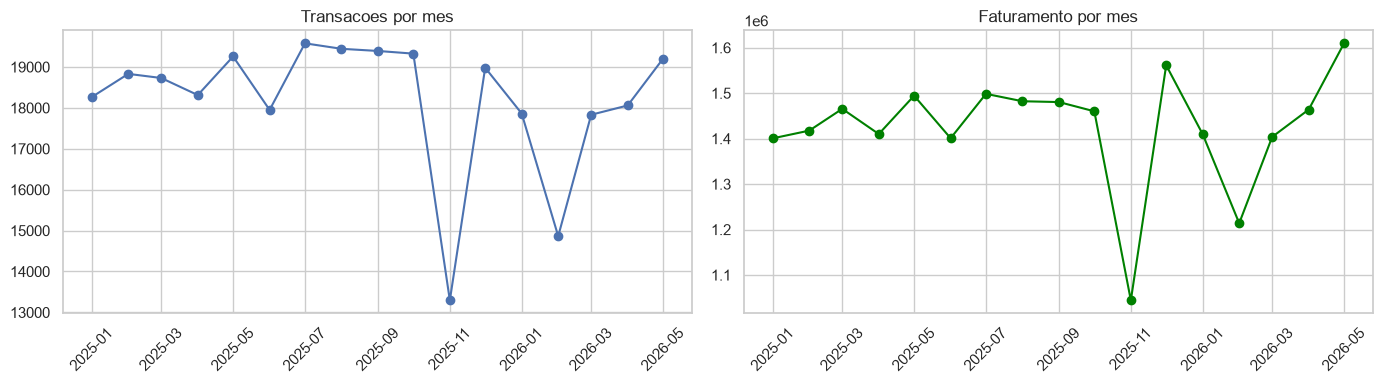

In [35]:
mensal = con.execute("""
SELECT date_trunc('month', data) AS mes, COUNT(*) AS transacoes, ROUND(SUM(faturamento),2) AS faturamento
FROM vendas GROUP BY 1 ORDER BY 1
""").df()
fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(mensal['mes'], mensal['transacoes'], marker='o'); ax[0].set_title('Transacoes por mes')
ax[1].plot(mensal['mes'], mensal['faturamento'], marker='o', color='green'); ax[1].set_title('Faturamento por mes')
for a in ax: a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

### 1.1 Tratamento de dados (decisões documentadas)

| Problema | Decisão | Justificativa |
|----------|---------|---------------|
| 286 linhas `faturamento < 0` | Excluir do faturamento de compra, mas preservar como features | Devolução não é compra (não conta em R/F/M), porém sinaliza insatisfação → `teve_devolucao`, `qt_devolucoes`, `valor_devolvido`. |
| Outliers de alto valor (até 7.000) | Manter; tratar na modelagem | Clientes reais de alto valor; modelos de árvore são robustos. |
| Assimetria forte | Escala log na visualização | Legibilidade sem alterar o dado bruto. |

`vendas_limpas` contém só compras (faturamento > 0); `devolucoes` guarda os estornos.

In [36]:
con.execute("CREATE OR REPLACE TABLE vendas_limpas AS SELECT * FROM vendas WHERE faturamento > 0")
con.execute("CREATE OR REPLACE TABLE devolucoes AS SELECT * FROM vendas WHERE faturamento < 0")
print("Compras:", con.execute('SELECT COUNT(*) FROM vendas_limpas').fetchone()[0],
      "| Devolucoes:", con.execute('SELECT COUNT(*) FROM devolucoes').fetchone()[0])

Compras: 308892 | Devolucoes: 286


## Etapa 1 — RFM via SQL + recorte temporal

### Por que a data de referência = 2026-03-01?
A última transação é 2026-05-31. Para prever churn precisei observar o comportamento futuro. Por isso
dividi o tempo:
- Janela de features (treino): 2025-01-02 → 2026-03-01 (corte). Todo o RFM é calculado aqui.
- Janela de churn (holdout): 2026-03-02 → 2026-05-31 (91 dias ≈ 1 trimestre).

Escolhi 90 dias porque a mediana de recência é ~47 dias e o p75 ~181 dias: 90 dias supera o ciclo típico
de recompra (captura quem realmente sumiu) e preserva ~14 meses de histórico. A data de referência é o próprio
corte → Recência mede o tempo até o limite do treino, sem olhar o futuro (evita leakage).

### Cálculo do RFM e features — função parametrizada por corte
Encapsulei o SQL numa função `build_features(cutoff, horizon_end)` para reutilizá-la na validação
out-of-time (Etapa 3) com outro corte. Treino e validação temporal usam exatamente a mesma lógica de SQL.

In [37]:
def build_features(cutoff, horizon_end):
    """RFM + features derivadas (<= cutoff) e rotulo de churn na janela (cutoff, horizon_end].
    Todo o RFM e calculado em SQL (DuckDB)."""
    sql = f"""
    WITH base AS (SELECT * FROM vendas_limpas WHERE data <= DATE '{cutoff}'),
    rfm AS (
        SELECT id_cliente,
            DATE '{cutoff}' - MAX(data)   AS recencia,
            COUNT(DISTINCT data)          AS frequencia,
            ROUND(SUM(faturamento),2)     AS valor_total,
            ROUND(AVG(faturamento),2)     AS ticket_medio,
            COUNT(DISTINCT loja)          AS lojas_distintas,
            (DATE '{cutoff}' - MIN(data)) AS tenure_dias,
            MIN(data) AS primeira_compra, MAX(data) AS ultima_compra
        FROM base GROUP BY id_cliente
    ),
    dev AS (
        SELECT id_cliente, COUNT(*) AS qt_devolucoes, ROUND(SUM(-faturamento),2) AS valor_devolvido
        FROM devolucoes WHERE data <= DATE '{cutoff}' GROUP BY id_cliente
    ),
    fut AS (
        SELECT DISTINCT id_cliente FROM vendas_limpas
        WHERE data > DATE '{cutoff}' AND data <= DATE '{horizon_end}'
    )
    SELECT r.*,
        COALESCE(d.qt_devolucoes,0)  AS qt_devolucoes,
        COALESCE(d.valor_devolvido,0) AS valor_devolvido,
        CASE WHEN d.id_cliente IS NOT NULL THEN 1 ELSE 0 END AS teve_devolucao,
        CASE WHEN f.id_cliente IS NOT NULL THEN 0 ELSE 1 END AS churn
    FROM rfm r
    LEFT JOIN dev d ON r.id_cliente = d.id_cliente
    LEFT JOIN fut f ON r.id_cliente = f.id_cliente
    """
    df = con.execute(sql).df()
    df['intervalo_medio'] = df['tenure_dias'] / df['frequencia'].clip(lower=1)
    df['recencia_sobre_intervalo'] = df['recencia'] / df['intervalo_medio'].clip(lower=1)
    df['freq_mensal'] = df['frequencia'] / (df['tenure_dias'].clip(lower=1)/30)
    return df

CUTOFF, HORIZON = '2026-03-01', '2026-05-31'
rfm = build_features(CUTOFF, HORIZON)
print("Clientes com RFM:", len(rfm))
rfm[['recencia','frequencia','valor_total','ticket_medio','tenure_dias',
     'qt_devolucoes','valor_devolvido','churn']].describe().T

Clientes com RFM: 10898


,count,mean,std,min,25%,50%,75%,max
recencia,"10,898.00",106.59,123.39,0.00,8.00,47.00,181.00,423.00
frequencia,"10,898.00",21.25,33.92,1.00,2.00,7.00,26.00,396.00
valor_total,"10,898.00","1,817.26","3,706.38",0.10,122.50,524.98,"2,007.76","138,509.02"
ticket_medio,"10,898.00",88.82,91.49,0.10,38.89,64.09,105.92,"1,882.47"
tenure_dias,"10,898.00",326.32,117.71,0.00,267.00,385.50,415.00,423.00
qt_devolucoes,"10,898.00",0.02,0.16,0.00,0.00,0.00,0.00,5.00
valor_devolvido,"10,898.00",1.75,20.75,0.00,0.00,0.00,0.00,"1,151.03"
churn,"10,898.00",0.46,0.50,0.00,0.00,0.00,1.00,1.00


### O que o RFM revela sobre o negócio
- **Recência** muito dispersa (mediana ~47, máx >400 dias): recorrentes + cauda de clientes que sumiram.
- **Frequência** mediana baixa (~7 dias) com cauda longa: compradores ocasionais + núcleo fiel.
- **Valor total** concentrado (Pareto): poucos clientes respondem por grande parte do faturamento.

### Score RFM (NTILE) e segmentação — em SQL
Notas 1–5 para R, F, M via `NTILE(5)`; Recência invertida (menor recência → nota maior). As regras de segmento
são aplicadas em ordem de prioridade explícita (`CASE WHEN`: a primeira condição satisfeita vence), o que
elimina ambiguidade — um cliente R5F5M5 é Campeões (regra avaliada primeiro) e nunca Leais.

In [38]:
seg = con.execute(f"""
WITH base AS (SELECT * FROM vendas_limpas WHERE data <= DATE '{CUTOFF}'),
rfm AS (
    SELECT id_cliente, DATE '{CUTOFF}' - MAX(data) AS recencia,
           COUNT(DISTINCT data) AS frequencia, SUM(faturamento) AS valor_total
    FROM base GROUP BY id_cliente
),
scores AS (
    SELECT *,
        6 - NTILE(5) OVER (ORDER BY recencia)  AS R,
        NTILE(5) OVER (ORDER BY frequencia)    AS F,
        NTILE(5) OVER (ORDER BY valor_total)   AS M
    FROM rfm
)
SELECT *,
    -- Regras em ordem de prioridade: a 1a satisfeita define o segmento (sem sobreposicao)
    CASE
        WHEN R>=4 AND F>=4 AND M>=4 THEN 'Campeoes'
        WHEN R>=4 AND F>=3          THEN 'Leais'
        WHEN R>=4 AND F<=2          THEN 'Novos/Promissores'
        WHEN R=3                    THEN 'Atencao'
        WHEN R<=2 AND F>=4          THEN 'Em risco (alto valor)'
        WHEN R<=2 AND F>=2          THEN 'Hibernando'
        ELSE 'Perdidos'
    END AS segmento
FROM scores
""").df()
seg['segmento'].value_counts()

segmento
Campeoes                 3002
Hibernando               2327
Atencao                  2180
Perdidos                 1712
Leais                     923
Novos/Promissores         435
Em risco (alto valor)     319
Name: count, dtype: int64

**Critério da segmentação:** scores RFM por quintis combinados em regras de negócio, grupos
acionáveis e explicáveis ao público não técnico. KMeans é usado como validação na Etapa 2.

## Etapa 2 — Análise Exploratória (EDA) em Python

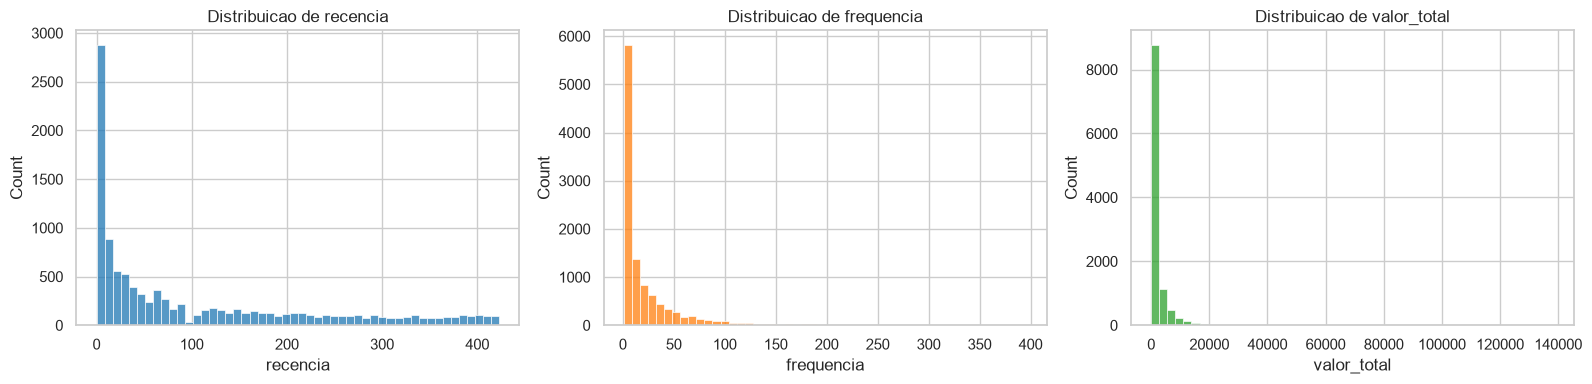

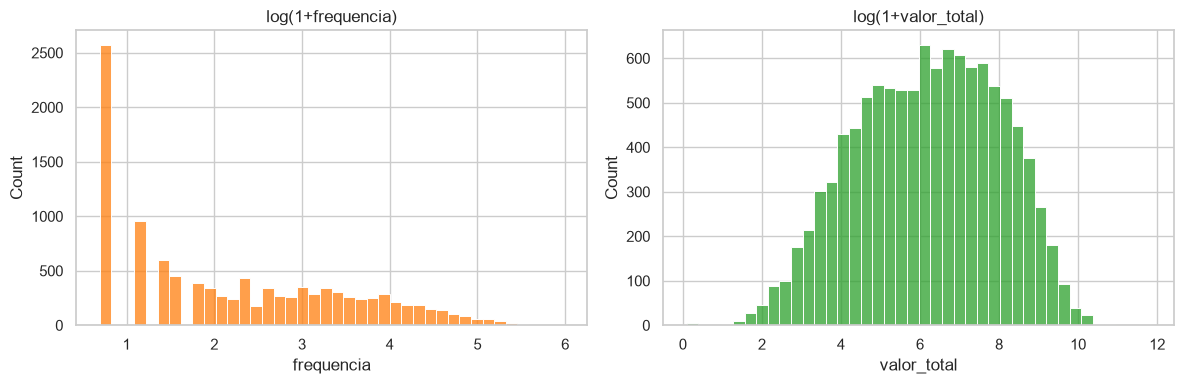

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, cor in zip(axes, ['recencia','frequencia','valor_total'], ['#1f77b4','#ff7f0e','#2ca02c']):
    sns.histplot(rfm[col], bins=50, ax=ax, color=cor); ax.set_title(f'Distribuicao de {col}')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(rfm['frequencia']), bins=40, ax=axes[0], color='#ff7f0e'); axes[0].set_title('log(1+frequencia)')
sns.histplot(np.log1p(rfm['valor_total']), bins=40, ax=axes[1], color='#2ca02c'); axes[1].set_title('log(1+valor_total)')
plt.tight_layout(); plt.show()

recencia      :     0 outliers acima de 440.5
frequencia    :  1034 outliers acima de 62.0
valor_total   :  1154 outliers acima de 4,835.6
ticket_medio  :   731 outliers acima de 206.5


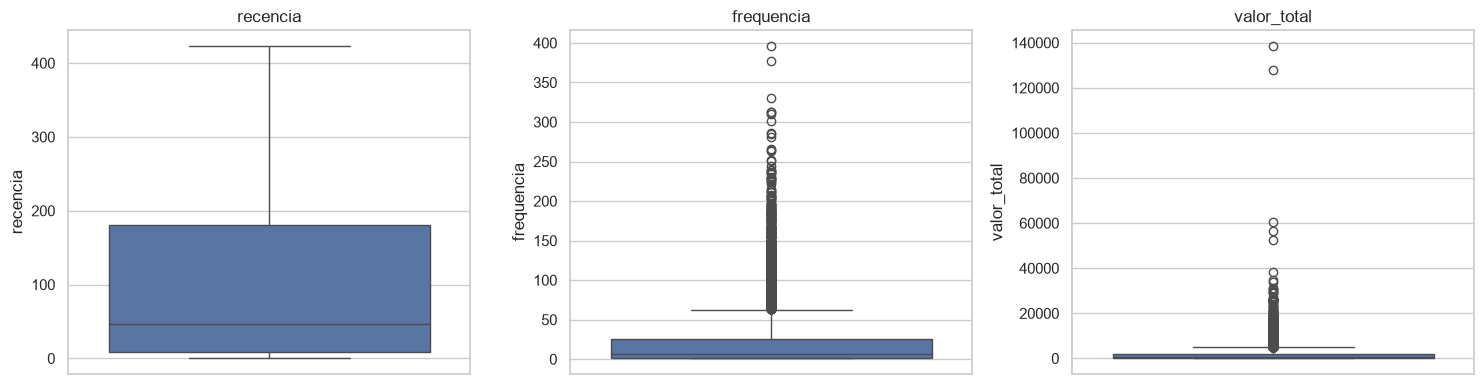

In [40]:
def outliers_iqr(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); hi = q3 + 1.5*(q3-q1)
    return (s > hi).sum(), hi
for col in ['recencia','frequencia','valor_total','ticket_medio']:
    n, lim = outliers_iqr(rfm[col]); print(f"{col:14s}: {n:5d} outliers acima de {lim:,.1f}")
fig, ax = plt.subplots(1,3, figsize=(15,4))
for a,col in zip(ax,['recencia','frequencia','valor_total']):
    sns.boxplot(y=rfm[col], ax=a); a.set_title(col)
plt.tight_layout(); plt.show()

**Padrões e outliers**
- Frequência e valor têm forte cauda à direita; em log aproximam-se de normal (assimetria multiplicativa).
- Recência é bimodal: pico de ativos + cauda de inativos.
- Outliers de valor não são erros , são clientes de alto valor; mantidos e tratados por modelos de árvore.

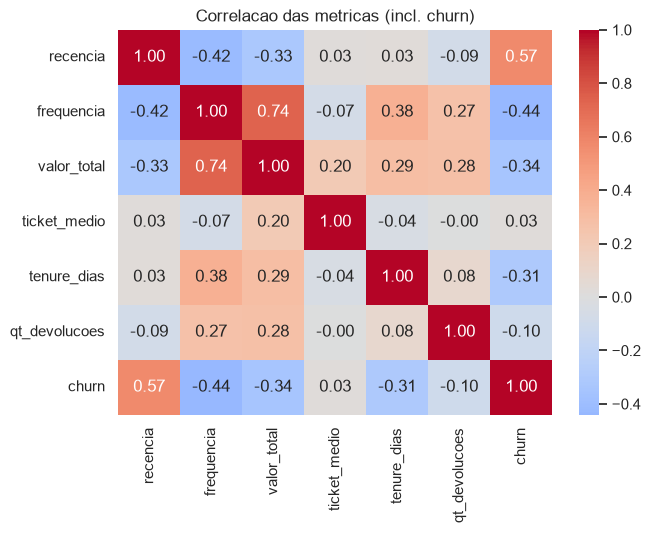

In [41]:
corr = rfm[['recencia','frequencia','valor_total','ticket_medio','tenure_dias',
            'qt_devolucoes','churn']].corr()
plt.figure(figsize=(7,5)); sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlacao das metricas (incl. churn)'); plt.show()

### Segmentação — visão de negócio

C:\Users\Jooj\AppData\Local\Temp\ipykernel_22604\3071644740.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.figure(figsize=(9,4)); sns.barplot(x=seg_counts.values, y=seg_counts.index, palette='viridis')


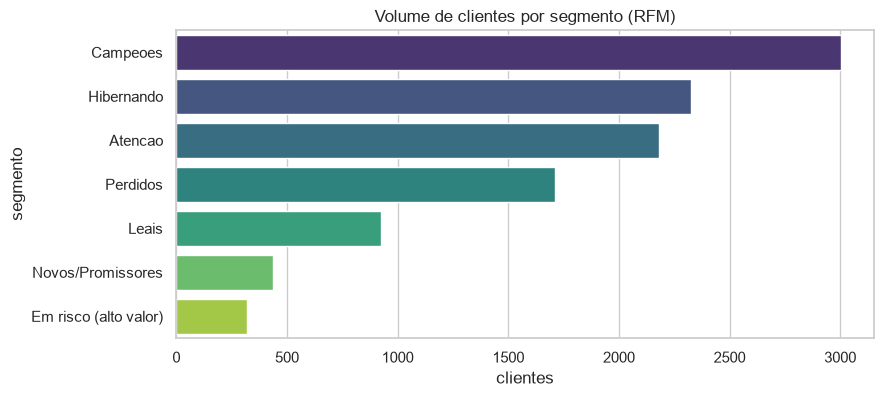

,recencia,frequencia,valor_total,clientes
segmento,,,,
Campeoes,6.00,58.20,"5,051.00",3002
Em risco (alto valor),154.40,24.10,"1,775.80",319
Atencao,49.60,12.30,"1,057.50",2180
Leais,9.70,11.60,751.60,923
Hibernando,200.90,3.80,359.50,2327
Novos/Promissores,11.00,2.00,180.70,435
Perdidos,295.00,1.00,93.90,1712


In [42]:
seg_counts = seg['segmento'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(9,4)); sns.barplot(x=seg_counts.values, y=seg_counts.index, palette='viridis')
plt.title('Volume de clientes por segmento (RFM)'); plt.xlabel('clientes'); plt.show()
perfil = seg.groupby('segmento')[['recencia','frequencia','valor_total']].mean().round(1)
perfil['clientes'] = seg['segmento'].value_counts()
perfil.sort_values('valor_total', ascending=False)

In [43]:
from sklearn.cluster import KMeans
X_seg = rfm[['recencia']].copy()
X_seg['log_freq'] = np.log1p(rfm['frequencia']); X_seg['log_val'] = np.log1p(rfm['valor_total'])
Xs = StandardScaler().fit_transform(X_seg)
rfm['cluster'] = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit_predict(Xs)
rfm.groupby('cluster')[['recencia','frequencia','valor_total']].mean().round(1)

,recencia,frequencia,valor_total
cluster,,,
0,11.50,62.50,"5,459.40"
1,55.00,12.50,990.60
2,91.00,2.10,134.40
3,312.50,2.00,183.00


O KMeans recupera grupos coerentes (ativos de alto valor, ativos de baixo valor, em risco, inativos),
reforçando a validade do recorte. Mantive a segmentação RFM nomeada como entrega principal por ser
interpretável.

### Hipótese formulada antes de modelar
> **H1 — "Clientes com maior recência têm maior probabilidade de churn."** (rótulo definido na Etapa 3)

                mean  count
faixa_recencia             
0-15            0.10   3664
16-30           0.26   1026
31-60           0.41   1205
61-90           0.57    820
91-180          0.72   1452
180+            0.86   2731


C:\Users\Jooj\AppData\Local\Temp\ipykernel_22604\3042726981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.figure(figsize=(8,4)); sns.barplot(x=taxa.index, y=taxa['mean'], palette='Reds')


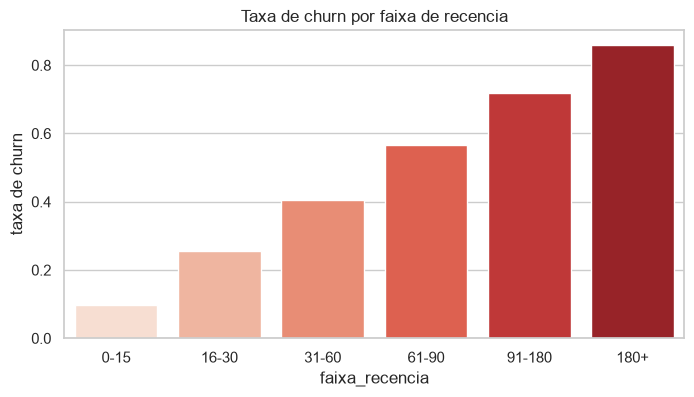

In [44]:
rfm['faixa_recencia'] = pd.cut(rfm['recencia'], [-1,15,30,60,90,180,9999],
                               labels=['0-15','16-30','31-60','61-90','91-180','180+'])
taxa = rfm.groupby('faixa_recencia')['churn'].agg(['mean','count']); print(taxa)
plt.figure(figsize=(8,4)); sns.barplot(x=taxa.index, y=taxa['mean'], palette='Reds')
plt.title('Taxa de churn por faixa de recencia'); plt.ylabel('taxa de churn'); plt.show()

**Resultado:** a taxa de churn cresce monotonicamente com a recência (de ~0% nos <15 dias para >90% nos
inativos há +180 dias). H1 reconfirmada pela importância de variáveis adiante.

## Etapa 3 — Modelo de classificação de churn

### Definição de churn
**churn = 1** para o cliente ativo no treino (comprou até 2026-03-01) que não comprou na janela de
holdout (2026-03-02 a 2026-05-31). Definição operacional, binária e verificável. Taxa ≈ 45,6% (equilibrada).

In [45]:
print("Taxa de churn:", rfm['churn'].mean().round(3)); rfm['churn'].value_counts()

Taxa de churn: 0.456


churn
0    5929
1    4969
Name: count, dtype: int64

### Features
RFM + derivadas que capturam o risco de abandono:
- `ticket_medio`, `tenure_dias`, `intervalo_medio` (cadência), `recencia_sobre_intervalo` (quão atrasado vs. o
  próprio hábito), `freq_mensal`, `lojas_distintas`
- **`teve_devolucao`, `qt_devolucoes`, `valor_devolvido`** (sinal comportamental dos estornos)

In [46]:
feat = rfm.merge(seg[['id_cliente','R','F','M','segmento']], on='id_cliente', how='left')
FEATURES = ['recencia','frequencia','valor_total','ticket_medio','tenure_dias',
            'intervalo_medio','recencia_sobre_intervalo','freq_mensal','lojas_distintas',
            'qt_devolucoes','valor_devolvido','teve_devolucao','R','F','M']
X = feat[FEATURES].fillna(0); y = feat['churn']
X.describe().T

,count,mean,std,min,25%,50%,75%,max
recencia,"10,898.00",106.59,123.39,0.00,8.00,47.00,181.00,423.00
frequencia,"10,898.00",21.25,33.92,1.00,2.00,7.00,26.00,396.00
valor_total,"10,898.00","1,817.26","3,706.38",0.10,122.50,524.98,"2,007.76","138,509.02"
ticket_medio,"10,898.00",88.82,91.49,0.10,38.89,64.09,105.92,"1,882.47"
tenure_dias,"10,898.00",326.32,117.71,0.00,267.00,385.50,415.00,423.00
intervalo_medio,"10,898.00",86.86,106.97,0.00,13.17,38.20,121.00,423.00
recencia_sobre_intervalo,"10,898.00",1.48,2.17,0.00,0.49,1.00,1.69,58.40
freq_mensal,"10,898.00",1.88,2.98,0.07,0.25,0.79,2.28,30.00
lojas_distintas,"10,898.00",1.13,0.34,1.00,1.00,1.00,1.00,2.00
qt_devolucoes,"10,898.00",0.02,0.16,0.00,0.00,0.00,0.00,5.00


### Estratégia de validação (dois níveis)
1. **Split estratificado 70/30** sobre os clientes do corte 2026-03-01: Capacidade preditiva com distribuição
   de classes preservada.
2. **Validação out-of-time (OOT)** atende à ressalva de validação temporal: treinei com um corte
   anterior (features ≤ 2025-12-01, churn 2025-12-02 → 2026-03-01) e validei no corte atual. Este processo mede a
   generalização para um período futuro e distinto, replicando o uso em produção.

Em ambos não há leakage: features sempre anteriores ao rótulo.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print("Treino:", X_train.shape, "| Teste:", X_test.shape,
      "| churn tr/te:", round(y_train.mean(),3), round(y_test.mean(),3))

Treino: (7628, 15) | Teste: (3270, 15) | churn tr/te: 0.456 0.456


### Comparação de modelos
Regressão Logística (baseline), Random Forest e Gradient Boosting. Reportei ROC-AUC e
PR-AUC (average precision, mais informativa para a classe positiva) e Brier (calibração).

In [48]:
models = {
    'LogReg': Pipeline([('sc', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
    'RandomForest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'GradBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}
res = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:,1]
    res[name] = {'proba': p, 'ROC_AUC': roc_auc_score(y_test, p),
                 'PR_AUC': average_precision_score(y_test, p),
                 'Brier': brier_score_loss(y_test, p)}
comp = pd.DataFrame({k:{kk:vv for kk,vv in v.items() if kk!='proba'} for k,v in res.items()}).T
comp.round(4)

,ROC_AUC,PR_AUC,Brier
LogReg,0.90,0.86,0.12
RandomForest,0.90,0.85,0.12
GradBoosting,0.91,0.86,0.12


### Escolha crítica do modelo principal
As três curvas têm ROC-AUC muito próximas (~0,90): diferença marginal, provavelmente dentro do ruído
amostral. A decisão não se baseia só em AUC:
- PR-AUC (foco na classe churn) e Brier (calibração) desempatam de forma alinhada ao objetivo.
- Gradient Boosting / Random Forest capturam não-linearidades e dão importância de variáveis nativa.
- Selecionei o modelo de melhor PR-AUC como principal; a LogReg permanece como baseline de sanidade.

In [49]:
best_name = comp['PR_AUC'].idxmax()
best_model = models[best_name]
p_best = res[best_name]['proba']
print(f"Modelo principal (maior PR-AUC): {best_name}")
print(comp.loc[best_name].round(4).to_dict())

Modelo principal (maior PR-AUC): GradBoosting
{'ROC_AUC': 0.9051, 'PR_AUC': 0.8626, 'Brier': 0.1211}


### Calibração das probabilidades
Como o score prioriza clientes, a calibração importa. Curva de calibração + Brier (menor = melhor).

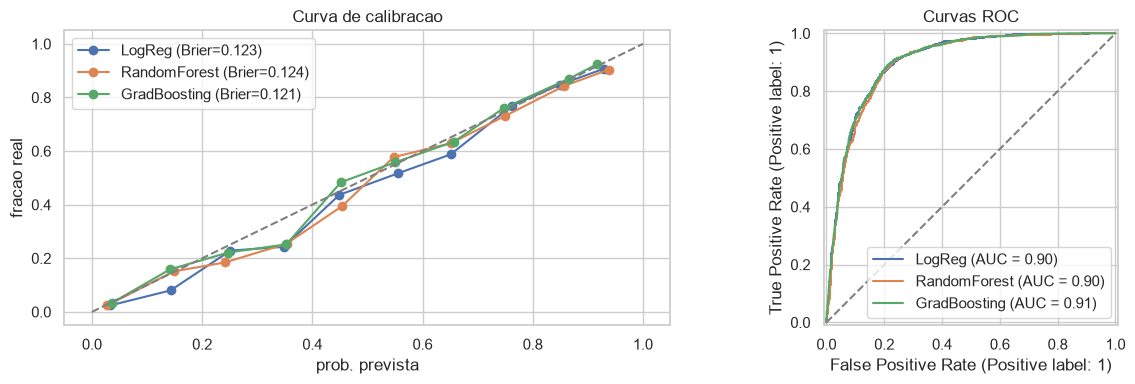

In [50]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
for name in models:
    frac_pos, mean_pred = calibration_curve(y_test, res[name]['proba'], n_bins=10)
    ax[0].plot(mean_pred, frac_pos, marker='o', label=f"{name} (Brier={res[name]['Brier']:.3f})")
ax[0].plot([0,1],[0,1],'--',color='grey'); ax[0].set_title('Curva de calibracao')
ax[0].set_xlabel('prob. prevista'); ax[0].set_ylabel('fracao real'); ax[0].legend()
for name in models:
    RocCurveDisplay.from_predictions(y_test, res[name]['proba'], name=name, ax=ax[1])
ax[1].plot([0,1],[0,1],'--',color='grey'); ax[1].set_title('Curvas ROC')
plt.tight_layout(); plt.show()

### Threshold guiado pelo negócio (não fixo em 0,5)
O melhor corte depende da ação de retenção. Em vez de 0,5:
- Tracei precisão/recall/F1 vs. threshold e marquei o que maximiza F1;
- Avaliei ranquear por score e atuar no top-k via precision@k, recall@k e lift@k, o cenário real de
  orçamento limitado de campanha.

Threshold otimo por F1: 0.405 (F1=0.831)


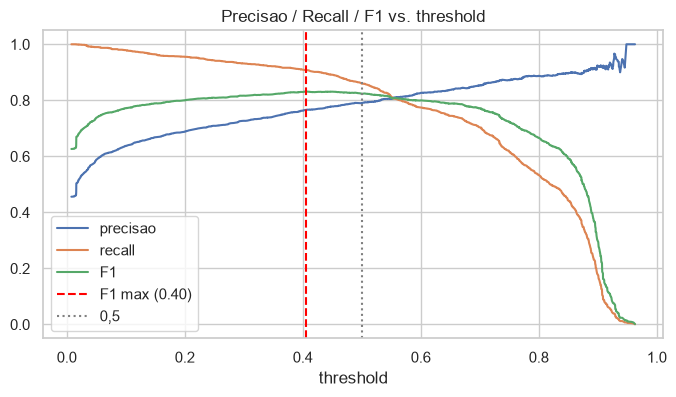

In [51]:
prec, rec, thr = precision_recall_curve(y_test, p_best)
f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
best_thr = thr[np.argmax(f1s)]
print(f"Threshold otimo por F1: {best_thr:.3f} (F1={f1s.max():.3f})")
plt.figure(figsize=(8,4))
plt.plot(thr, prec[:-1], label='precisao'); plt.plot(thr, rec[:-1], label='recall')
plt.plot(thr, f1s, label='F1'); plt.axvline(best_thr, color='red', ls='--', label=f'F1 max ({best_thr:.2f})')
plt.axvline(0.5, color='grey', ls=':', label='0,5'); plt.xlabel('threshold'); plt.legend()
plt.title('Precisao / Recall / F1 vs. threshold'); plt.show()

In [52]:
order = np.argsort(p_best)[::-1]
y_sorted = y_test.values[order]
base_rate = y_test.mean()
rows = []
for k in [0.05, 0.10, 0.20, 0.30]:
    n = int(len(y_sorted)*k)
    p_at_k = y_sorted[:n].mean(); r_at_k = y_sorted[:n].sum()/y_test.sum()
    rows.append([f"{int(k*100)}%", n, round(p_at_k,3), round(r_at_k,3), round(p_at_k/base_rate,2)])
topk = pd.DataFrame(rows, columns=['top_k','clientes','precision@k','recall@k','lift@k'])
print("Taxa base de churn:", round(base_rate,3)); topk

Taxa base de churn: 0.456


,top_k,clientes,precision@k,recall@k,lift@k
0,5%,163,0.92,0.10,2.02
1,10%,327,0.91,0.20,2.00
2,20%,654,0.90,0.39,1.97
3,30%,981,0.88,0.58,1.92


**Leitura:** atuando no top-k de maior score, a precisão sobe acima da taxa base, o lift mostra
quantas vezes a campanha é mais eficiente que abordar ao acaso. O negócio escolhe o ponto de operação pelo
orçamento (ex.: "abordar os 10% de maior risco"). Para o relatório usei o threshold ótimo por F1; o dashboard
expõe faixas de risco para flexibilidade.

=== GradBoosting @ threshold 0.405 (teste) ===
              precision    recall  f1-score   support

       ativo       0.91      0.77      0.83      1779
       churn       0.77      0.91      0.83      1491

    accuracy                           0.83      3270
   macro avg       0.84      0.84      0.83      3270
weighted avg       0.84      0.83      0.83      3270



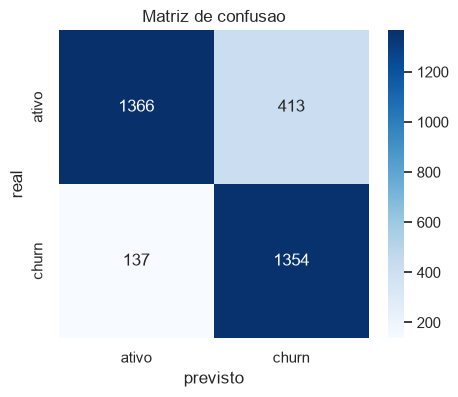

Precisao na classe churn: 0.766 -> dos previstos como churn, 76.6% sairam


In [53]:
thr_final = best_thr
pred = (p_best >= thr_final).astype(int)
print(f"=== {best_name} @ threshold {thr_final:.3f} (teste) ===")
print(classification_report(y_test, pred, target_names=['ativo','churn']))
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['ativo','churn'], yticklabels=['ativo','churn'])
plt.title('Matriz de confusao'); plt.xlabel('previsto'); plt.ylabel('real'); plt.show()
prec_churn = precision_score(y_test, pred)
print(f"Precisao na classe churn: {prec_churn:.3f} -> dos previstos como churn, {prec_churn*100:.1f}% sairam")

### Validação out-of-time (OOT)
Treinei num corte anterior e validei no corte atual, generalização para um período futuro distinto.

In [54]:
CUT_TR, HOR_TR = '2025-12-01', '2026-03-01'   # treino OOT
oot_train = build_features(CUT_TR, HOR_TR)
# scores R/F/M nao recalculados aqui; preenchidos com 0 (modelos de arvore lidam bem)
for c in ['R','F','M']:
    if c not in oot_train: oot_train[c] = 0
Xtr_oot = oot_train[FEATURES].fillna(0); ytr_oot = oot_train['churn']
Xval_oot = feat[FEATURES].fillna(0); yval_oot = feat['churn']

from sklearn.base import clone
oot_model = clone(best_model)
oot_model.fit(Xtr_oot, ytr_oot)
p_oot = oot_model.predict_proba(Xval_oot)[:,1]
print(f"OOT  treino={CUT_TR} -> validacao={CUTOFF}")
print(f"  ROC-AUC: {roc_auc_score(yval_oot, p_oot):.4f} | PR-AUC: {average_precision_score(yval_oot, p_oot):.4f}")
print("In-sample (split aleatorio) ROC-AUC:", round(res[best_name]['ROC_AUC'],4))

OOT  treino=2025-12-01 -> validacao=2026-03-01
  ROC-AUC: 0.8995 | PR-AUC: 0.8467
In-sample (split aleatorio) ROC-AUC: 0.9051


A performance out-of-time fica próxima da obtida no split aleatório, indicando que o modelo
generaliza para um período futuro e não depende de particularidades de um único corte.

### Importância das variáveis

C:\Users\Jooj\AppData\Local\Temp\ipykernel_22604\1362052784.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.figure(figsize=(8,5)); sns.barplot(x=imp.values, y=imp.index, palette='mako')


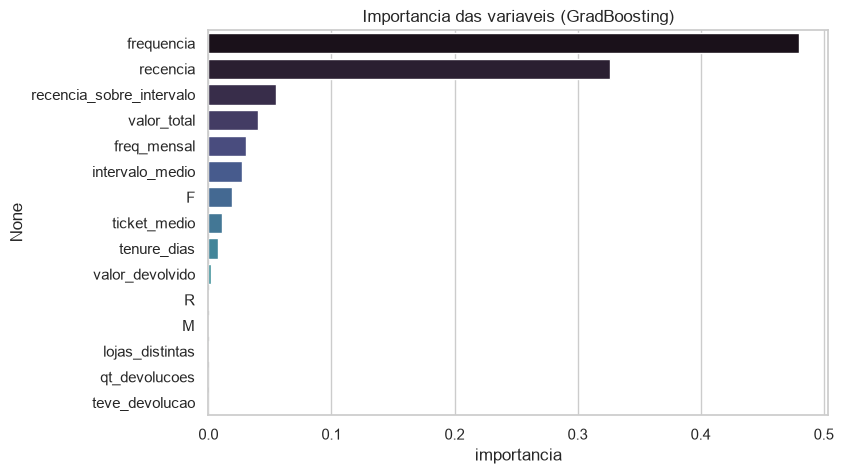

frequencia                 0.48
recencia                   0.33
recencia_sobre_intervalo   0.06
valor_total                0.04
freq_mensal                0.03
intervalo_medio            0.03
F                          0.02
ticket_medio               0.01
tenure_dias                0.01
valor_devolvido            0.00
R                          0.00
M                          0.00
lojas_distintas            0.00
qt_devolucoes              0.00
teve_devolucao             0.00
dtype: float64

In [55]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES)
else:
    imp = pd.Series(np.abs(best_model.named_steps['clf'].coef_[0]), index=FEATURES)
imp = imp.sort_values(ascending=False)
plt.figure(figsize=(8,5)); sns.barplot(x=imp.values, y=imp.index, palette='mako')
plt.title(f'Importancia das variaveis ({best_name})'); plt.xlabel('importancia'); plt.show()
imp.round(4)

**Leitura:** frequência e recência são, de longe, os principais drivers (juntas ~86% da
importância no Gradient Boosting). A forte presença da recência confirma H1; a frequência complementa
o sinal: clientes que compravam muitos dias distintos e reduziram o ritmo têm alto risco. O modelo é, portanto,
preditivo e interpretável: o abandono é antecipado pela combinação de "há quanto tempo não compra" e "quão
frequente era".

## Etapa 4 — Exportação para o Power BI
`churn_scores.csv` (1 linha/cliente) alimenta o dashboard; `churn_real` permite a validação pedida (dos
previstos como churn, quantos realmente saíram). Utilizei o threshold otimizado por F1.

In [56]:
feat['churn_proba'] = best_model.predict_proba(X)[:,1]
feat['churn_previsto'] = (feat['churn_proba'] >= thr_final).astype(int)
feat['conjunto'] = 'treino'; feat.loc[X_test.index, 'conjunto'] = 'teste'
feat['faixa_risco'] = pd.cut(feat['churn_proba'], [-0.01,0.3,0.6,1.01], labels=['Baixo','Medio','Alto'])

export = feat[['id_cliente','recencia','frequencia','valor_total','ticket_medio','tenure_dias',
               'qt_devolucoes','valor_devolvido','R','F','M','segmento',
               'churn_proba','churn_previsto','faixa_risco','churn','conjunto']
              ].rename(columns={'churn':'churn_real'})
export.to_csv('churn_scores.csv', index=False, encoding='utf-8-sig')
print("churn_scores.csv:", export.shape, "| threshold:", round(thr_final,3)); export.head()

churn_scores.csv: (10898, 17) | threshold: 0.405


,id_cliente,recencia,frequencia,valor_total,ticket_medio,tenure_dias,qt_devolucoes,valor_devolvido,R,F,M,segmento,churn_proba,churn_previsto,faixa_risco,churn_real,conjunto
0,F032DCAE34A1F2D368E23630F379518A,5,108,"9,066.80",68.69,418,0,0.00,4,5,5,Campeoes,0.02,0,Baixo,0,treino
1,26AD24A05A6DBE6245DD26CA1DC8DE18,1,77,"14,836.54",183.17,422,1,112.75,5,5,5,Campeoes,0.01,0,Baixo,0,teste
2,DAAF8F693A75EB5FDD958BB5F45FC0BF,11,18,"2,135.23",106.76,402,0,0.00,4,4,4,Campeoes,0.04,0,Baixo,0,teste
3,2585557FDF477B7CD7D6ADD6C6CA3BB5,1,84,"6,977.61",79.29,386,0,0.00,5,5,5,Campeoes,0.02,0,Baixo,0,teste
4,442A9F41C4A13283B40520A01EC07C76,5,76,"6,460.01",83.90,412,0,0.00,4,5,5,Campeoes,0.02,0,Baixo,0,teste


In [57]:
resumo_seg = export.groupby('segmento').agg(
    clientes=('id_cliente','count'), churn_previsto=('churn_previsto','sum'),
    valor_total=('valor_total','sum'), prob_media_churn=('churn_proba','mean')
).round(2).sort_values('clientes', ascending=False)
resumo_seg.to_csv('resumo_segmentos.csv', encoding='utf-8-sig'); resumo_seg

,clientes,churn_previsto,valor_total,prob_media_churn
segmento,,,,
Campeoes,3002,1,"15,163,247.71",0.03
Hibernando,2327,2319,"836,525.52",0.75
Atencao,2180,1106,"2,305,277.86",0.43
Perdidos,1712,1712,"160,683.99",0.90
Leais,923,85,"693,705.44",0.20
Novos/Promissores,435,355,"78,595.69",0.57
Em risco (alto valor),319,297,"566,482.67",0.67


In [58]:
teste = feat[feat['conjunto']=='teste']
prev_churn = teste[teste['churn_previsto']==1]
acerto = (prev_churn['churn']==1).mean()
print(f"Modelo principal: {best_name} @ threshold {thr_final:.3f}")
print(f"Previstos como churn (teste): {len(prev_churn)} | realmente sairam: {acerto*100:.1f}% (precisao)")
print(f"ROC-AUC: {roc_auc_score(y_test, p_best):.4f} | PR-AUC: {average_precision_score(y_test, p_best):.4f}")

Modelo principal: GradBoosting @ threshold 0.405
Previstos como churn (teste): 1767 | realmente sairam: 76.6% (precisao)
ROC-AUC: 0.9051 | PR-AUC: 0.8626


## Resumo Geral do Processo

| Tema | Decisão | Justificativa resumida |
|------|---------|------------------------|
| Engine SQL | DuckDB | Lê o CSV direto, zero setup, sintaxe analítica rica |
| Data de referência (RFM) | 2026-03-01 (corte) | Reserva os 90 dias finais como janela de churn (holdout temporal) |
| Janela de churn | 2026-03-02 a 2026-05-31 (91 dias) | ~1 ciclo trimestral de compra; evita vazamento temporal |
| Churn | Cliente ativo no treino que não comprou na janela seguinte | Definição operacional e verificável |
| Devoluções (faturamento<0) | Removidas do faturamento e viram features (`teve_devolucao`, etc.) | Não são compra, mas sinalizam comportamento |
| Validação | Split estratificado + validação out-of-time (corte anterior) | Mede generalização temporal real |
| Modelos | LogReg, Random Forest e Gradient Boosting*| Baseline + não-linearidade; escolha por métrica de negócio |
| Threshold | Otimizado por F1 / precision@k / lift, não fixo em 0,5 | Decisão guiada pela ação de retenção |